# Feature and more

## Justification rétrospective de certains choix

In [7]:

import scipy.stats as stats
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 🌡️ Comprendre les unités : kBtu et émissions de CO₂e

### 🔋 1. Qu’est-ce que le `SiteEnergyUse(kBtu)` ?

La colonne `SiteEnergyUse(kBtu)` indique la **consommation totale d'énergie annuelle d’un bâtiment**, exprimée en **kBtu**, soit :

- **1 kBtu** = 1 000 **British thermal units**
- **1 Btu** ≈ 1 055 joules
- Donc **1 kBtu ≈ 0.293 kWh**

> 👉 Un bâtiment qui consomme 14 172 606 kBtu/an utilise environ **4,15 millions de kWh/an**,  
> soit **autant que 346 maisons individuelles** (moyenne de 12 000 kWh/an par maison).

### 🌪️ 2. Et `SiteEnergyUseWN(kBtu)` ? Quelle différence ?

`SiteEnergyUseWN(kBtu)` signifie **"Site Energy Use - Weather Normalized"**, c’est-à-dire :

> ⚠️ **Consommation énergétique corrigée des variations climatiques**

- Cela représente **ce qu’aurait été la consommation du bâtiment dans une année météo "standardisée"**
- Elle permet de **neutraliser l’effet des hivers plus froids ou des étés plus chauds**
- C’est une **valeur modélisée** utile pour comparer équitablement plusieurs bâtiments d’une même région

> 📌 Exemple :
> - `SiteEnergyUse(kBtu)` = 15 000 000 → année réellement froide
> - `SiteEnergyUseWN(kBtu)` = 12 800 000 → consommation estimée sans ce froid excessif

### 🧪 Dans quels cas cette variable est-elle utile ?

Cette valeur **modélisée** est précieuse dans certains contextes :

| Cas d’usage                                    | Pourquoi l’utiliser ?                                      |
|------------------------------------------------|-------------------------------------------------------------|
| 📊 Benchmark énergétique entre bâtiments       | Supprime les biais dus aux différences climatiques locales |
| 🔁 Suivi d’un bâtiment d’année en année        | Neutralise les hivers anormaux ou étés extrêmes            |
| 🏛️ Politiques publiques / subventions         | Permet une évaluation équitable de l'efficacité réelle     |
| 📈 Études structurelles sur la performance     | Permet de comparer "structurellement" les bâtiments        |

---

### ❌ Pourquoi **ne PAS** l’utiliser ici ?

Notre objectif est de **prédire la consommation d’énergie réelle** (`SiteEnergyUse(kBtu)`) d’un bâtiment.  
Autrement dit, **ce que le compteur mesurera** (et ce qui sera facturé).

Utiliser la version "normalisée climat" serait problématique pour 3 raisons :

1. **Non observable** : on ne connaît pas `SiteEnergyUseWN(kBtu)` avant d’avoir mesuré l’année.
2. **Inclut déjà un modèle** : elle est le résultat d’un ajustement statistique → risque de **data leakage**.
3. **Pas fidèle à la réalité terrain** : notre modèle vise une prédiction "terrain", pas une estimation abstraite.

---

### ✅ En résumé

| Variable               | À utiliser ? | Raisonnement                                  |
|------------------------|--------------|-----------------------------------------------|
| `SiteEnergyUse(kBtu)`  | ✅ OUI       | Cible réelle, mesurée, conforme au terrain    |
| `SiteEnergyUseWN(kBtu)`| ❌ NON       | Valeur modélisée                              |


### 🌍 3. Qu’est-ce que le `TotalGHGEmissions` ?

La colonne `TotalGHGEmissions` représente les **émissions annuelles totales de gaz à effet de serre**,  
exprimées en **tonnes métriques de CO₂ équivalent** (tCO₂e).

> 👉 Par exemple, **1699.45 tCO₂e/an** équivalent à :
> - **212 maisons individuelles**
> - **~850 vols aller-retour Paris – New York**


### 🔁 4. Comment sont calculées les émissions de CO₂ ?

Les émissions sont dérivées de la **consommation d’énergie** pondérée par les **facteurs d’émission** propres à chaque source :

$\text{TotalGHGEmissions} = \sum_i \left( \text{Energy}_i \times \text{EmissionFactor}_i \right)$


| Source énergétique | Facteur d’émission (kg CO₂ / kBtu) |
|--------------------|-------------------------------------|
| Électricité (USA)  | 0.293                              |
| Gaz naturel        | 0.053                              |
| Fioul              | 0.074                              |
| Énergies renouvelables | ~0                            |





count    1578.000000
mean        0.682743
std         0.261343
min         0.000000
25%         0.477184
50%         0.680457
75%         0.974967
90%         1.000000
95%         1.000000
max         1.000000
Name: Electricity_Proportion, dtype: float64


C:\Users\karap\AppData\Local\Temp\ipykernel_9124\2951883109.py:26: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\karap\OpenClassRooms\dataprojet6\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


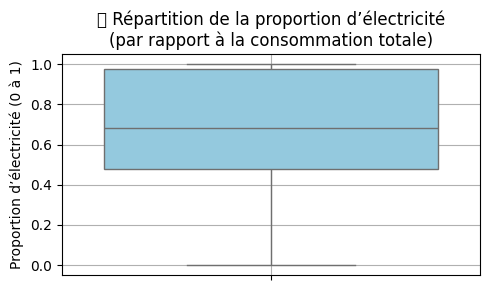

In [8]:

# 📂 Chargement des données nettoyées
df = pd.read_csv("data/2016_Building_Energy_Benchmarking_Purge.csv")

# 🔍 Recherche des colonnes d’électricité
electricity_cols = [col for col in df.columns if 'Electricity' in col and 'kBtu' in col]
total_energy_col = 'SiteEnergyUse(kBtu)'

# ✅ Création de la somme totale de consommation électrique (certaines colonnes sont divisées par usage)
df['Electricity_Use_Total'] = df[electricity_cols].sum(axis=1, skipna=True)

# ⚙️ Calcul du ratio de proportion d’électricité
df['Electricity_Proportion'] = df['Electricity_Use_Total'] / df[total_energy_col]

# 🔁 Nettoyage : garder les cas valides (entre 0 et 1)
df_valid_ratio = df[df['Electricity_Proportion'].between(0, 1)]

# 📊 Statistiques descriptives sur la proportion d’électricité
print(df_valid_ratio['Electricity_Proportion'].describe(percentiles=[.25, .5, .75, .9, .95]))

# 📦 Boxplot
plt.figure(figsize=(5, 3))
sns.boxplot(y=df_valid_ratio['Electricity_Proportion'], color='skyblue')
plt.title("📦 Répartition de la proportion d’électricité\n(par rapport à la consommation totale)")
plt.ylabel("Proportion d’électricité (0 à 1)")
plt.grid(True)
plt.tight_layout()
plt.show()


## ⚡ Poids réel de l’électricité dans la consommation énergétique des bâtiments

### 🎯 Objectif
Quantifier **dans quelle mesure l’électricité contribue à la consommation totale d’énergie** (`SiteEnergyUse(kBtu)`),  
et valider si un modèle basé sur la consommation totale peut capturer l’essentiel des **émissions de gaz à effet de serre**.

---

### 🔍 Méthode
- Extraction des colonnes de consommation électrique (kBtu).
- Somme des valeurs électriques → `Electricity_Use_Total`
- Calcul du ratio :
$
text{Electricity Proportion} = \frac{\text{Electricity\_Use\_Total}}{\text{SiteEnergyUse(kBtu)}}
$

---

### 📊 Résultats statistiques (sur 1578 bâtiments valides)

| Statistique       | Valeur           |
|-------------------|------------------|
| Moyenne           | **68.3 %**        |
| Médiane (50%)     | **68.0 %**        |
| 25e percentile     | 47.7 %           |
| 75e percentile     | 97.5 %           |
| 90e - 95e percentile | **100 %**       |
| Minimum            | 0 %              |
| Maximum            | 100 %            |

---

### 🧠 Interprétation
- Pour **la majorité des bâtiments**, l’électricité constitue la **source principale** d’énergie.
- Pour **plus de 10 % d’entre eux**, elle est **la seule source utilisée**.
- Cela **justifie pleinement** que la consommation totale soit fortement corrélée aux émissions de CO₂,  
puisque l’électricité est **la plus émettrice de CO₂ par kBtu** dans le contexte américain.

---

### ⚠️ Précautions d’usage
- Certains bâtiments combinent gaz, vapeur, fioul… L'effet de levier de l’électricité peut y être atténué.
- Lorsqu'il s'agira modéliser les émissions de CO₂ avec plus de précision, il faudra peut-être:
  - inclure la variable de consommation totale
  - ajouter des indicateurs binaires de source d’énergie
  - intégrer la proportion d’électricité comme feature explicite


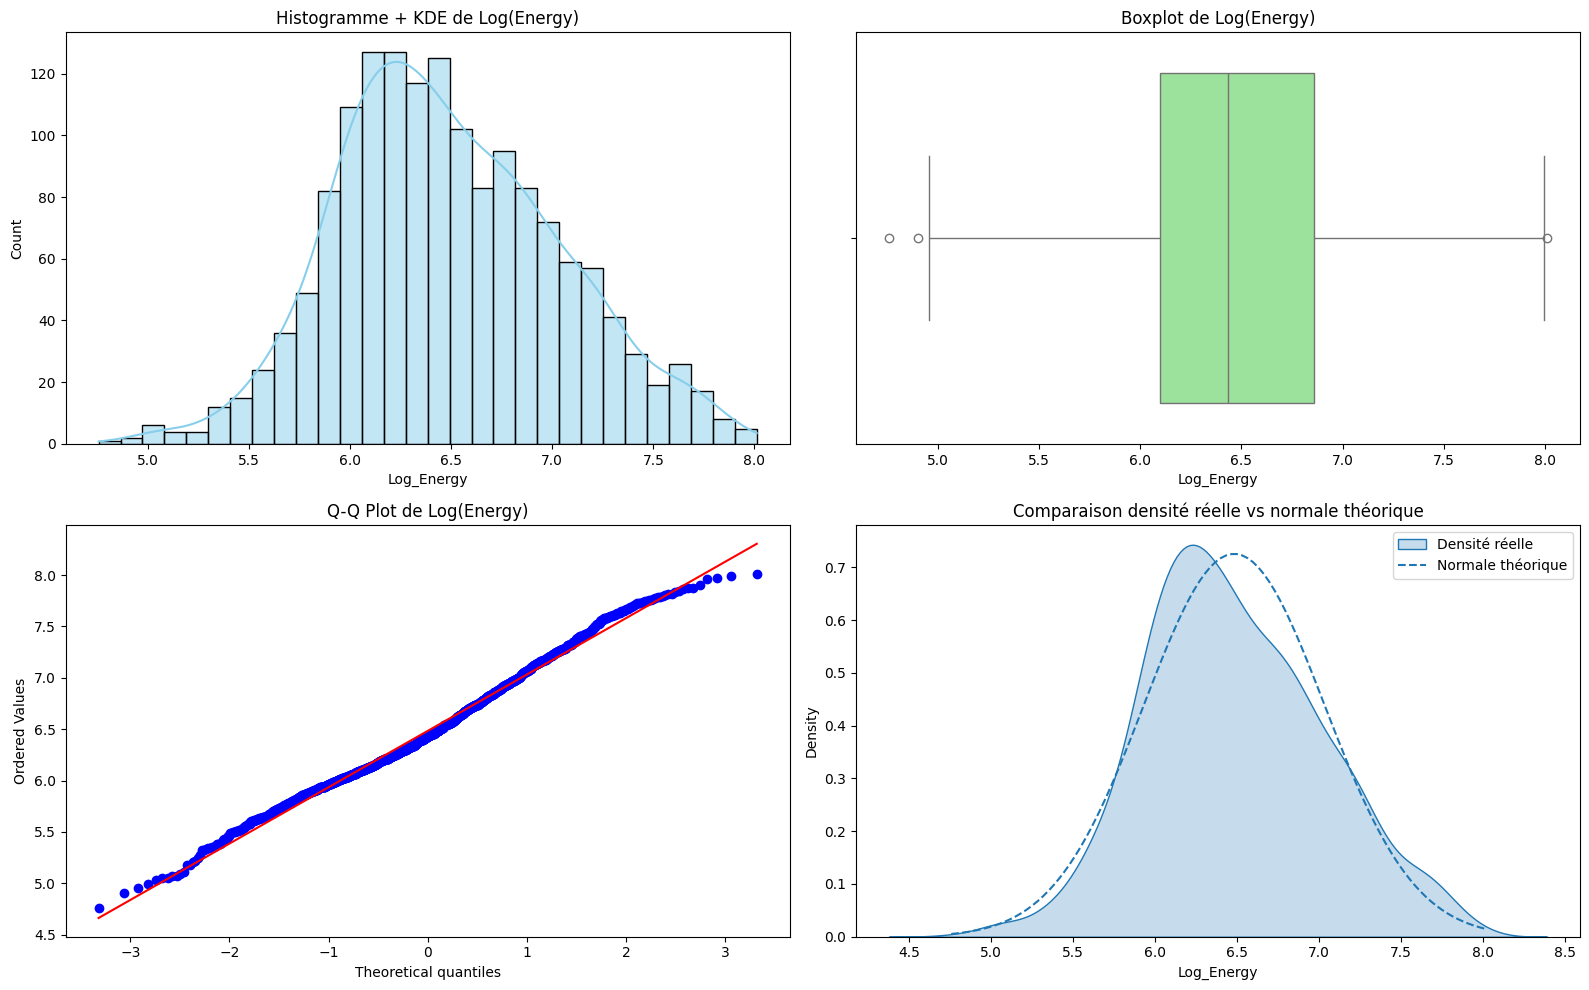

In [9]:
# repartons du bon pied ..
df = pd.read_csv("data/cleaned_2016_Building_Energy_Benchmarking_ML.csv")

assert 'SiteEnergyUse(kBtu)' in df.columns, "Colonne manquante"

# On garde la variable d'intérêt et on filtre les valeurs manquantes ou nulles
df = df[['SiteEnergyUse(kBtu)']].dropna()
df = df[df['SiteEnergyUse(kBtu)'] > 0]

# Transformation logarithmique pour atténuer les valeurs extrêmes
df['Log_Energy'] = np.log10(df['SiteEnergyUse(kBtu)'])

# Créer une figure avec plusieurs visualisations
plt.figure(figsize=(16, 10))

# 1. Histogramme + courbe KDE
plt.subplot(2, 2, 1)
sns.histplot(df['Log_Energy'], kde=True, bins=30, color='skyblue')
plt.title("Histogramme + KDE de Log(Energy)")

# 2. Boîte à moustaches (boxplot)
plt.subplot(2, 2, 2)
sns.boxplot(x=df['Log_Energy'], color='lightgreen')
plt.title("Boxplot de Log(Energy)")

# 3. Q-Q plot (quantile-quantile plot) pour tester la normalité
plt.subplot(2, 2, 3)
stats.probplot(df['Log_Energy'], dist="norm", plot=plt)
plt.title("Q-Q Plot de Log(Energy)")

# 4. Densité empirique comparée à la courbe normale
plt.subplot(2, 2, 4)
sns.kdeplot(df['Log_Energy'], label='Densité réelle', fill=True)
mean = df['Log_Energy'].mean()
std = df['Log_Energy'].std()
x = np.linspace(df['Log_Energy'].min(), df['Log_Energy'].max(), 100)
plt.plot(x, stats.norm.pdf(x, mean, std), label='Normale théorique', linestyle='--')
plt.title("Comparaison densité réelle vs normale théorique")
plt.legend()

plt.tight_layout()
plt.show()


## 🔍 Relation surface/consommation definitive

Dans cette visualisation :

* La **consommation énergétique totale (kBtu)** a été transformée en **échelle logarithmique** (`Log_Energy`), tout comme la surface utile (`Log_Surface`).
* Les **valeurs extrêmes** (outliers) ont été identifiées via la méthode IQR (1.5 × IQR au-dessus ou en-dessous des quartiles) puis **exclues** du graphique.

### 🎯 Objectifs de cette visualisation :

* Mettre en évidence la tendance **générale** entre la taille d’un bâtiment et sa consommation, **sans être perturbé par des cas extrêmes**.
* Faciliter l’identification d’une **relation linéaire potentielle** sur les données "propres".



✅ Données chargées : (1536, 17)


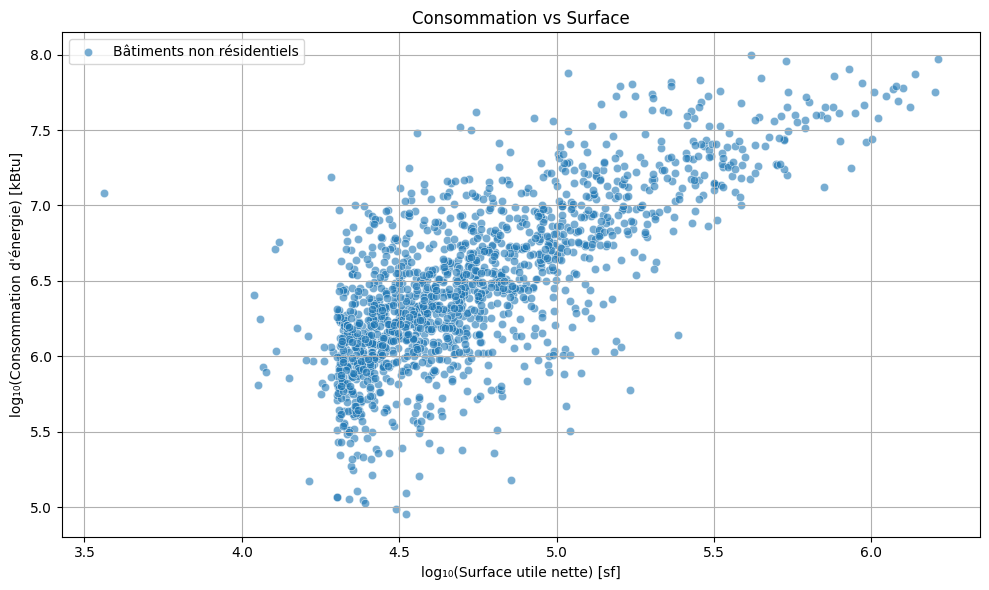

In [10]:

# 🔹 Étape 1 : Charger les données nettoyées
df = pd.read_csv("data/cleaned_2016_Building_Energy_Benchmarking_ML.csv")
print("✅ Données chargées :", df.shape)

# 🔹 Étape 2 : Log-transformations
df['Log_Surface'] = np.log10(df['PropertyGFABuilding(s)'] + 1)
df['Log_Energy'] = np.log10(df['SiteEnergyUse(kBtu)'] + 1)

# 🔹 Étape 3 : Calcul des bornes IQR
Q1 = df['Log_Energy'].quantile(0.25)
Q3 = df['Log_Energy'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 🔹 Étape 4 : Filtrer les bâtiments normaux (hors outliers)
df_normal = df[(df['Log_Energy'] >= lower_bound) & (df['Log_Energy'] <= upper_bound)]

# 🔹 Étape 5 : Visualisation des bâtiments non résicentiels uniquement
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_normal, x='Log_Surface', y='Log_Energy', alpha=0.6, label="Bâtiments non résidentiels")
plt.xlabel("log₁₀(Surface utile nette) [sf]")
plt.ylabel("log₁₀(Consommation d'énergie) [kBtu]")
plt.title("Consommation vs Surface")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



## 📊 Analyse visuelle de la consommation énergétique des bâtiments

### 🎯 Objectif de cette section

Dans ce bloc, nous analysons la **consommation énergétique des bâtiments** (`SiteEnergyUse(kBtu)`) en lien avec plusieurs variables explicatives possibles, afin de mieux comprendre les **facteurs associés à des consommations élevées ou faibles**.

---

### ⚙️ Variables utilisées

| Nom de la variable       | Signification                                                                                       |
| ------------------------ | --------------------------------------------------------------------------------------------------- |
| `SiteEnergyUse(kBtu)`    | Consommation d’énergie totale du site en kBtu                                                       |
| `Electricity(kBtu)`      | Électricité consommée                                                                               |
| `SteamUse(kBtu)`         | Vapeur utilisée                                                                                     |
| `NaturalGas(kBtu)`       | Gaz naturel consommé                                                                                |
| `PourcentElec`           | Part de l’électricité dans l’énergie totale (en %)                                                  |
| `HasParking`             | Présence (ou non) de surface de parking                                                             |
| `LargestPropertyUseType` | Type principal d’usage du bâtiment                                                                  |
| `log_energy`             | Transformation logarithmique de la conso. totale (`log1p`) pour améliorer la lisibilité des graphes |

---

### 🔧 Pré-traitements effectués

* Suppression des lignes avec valeurs manquantes ou incohérentes.
* Transformation `log1p` sur la consommation d’énergie pour **réduire l’influence des très grands bâtiments**.
* Calcul de la part d’électricité dans la conso. énergétique totale :

$text{PourcentElec} = \left( \frac{\text{Electricity(kBtu)}}{\text{Electricity + Steam + Natural Gas (kBtu)}} \right) \times 100$

---

## 📈 Visualisation A — Relation entre part d’électricité et consommation

> **Type : Nuage de points avec ligne de régression**

* **X** : Pourcentage d’électricité dans la consommation totale (`PourcentElec`)
* **Y** : `log_energy`
* **Interprétation :**

  * Une **tendance ascendante** suggérerait que les bâtiments très électrifiés sont plus consommateurs.
  * Une **tendance descendante** pourrait indiquer un meilleur rendement ou une dominance d’énergie propre.

---

## 📊 Visualisation B — Influence de la présence de parking

> **Type : Boxplot (2 groupes)**

* Groupes :

  * Sans parking (`HasParking = False`)
  * Avec parking (`HasParking = True`)
* Variable étudiée : `log_energy`
* **Interprétation possible :**

  * Si les bâtiments avec parking consomment davantage, cela peut s’expliquer par :

    * Leur plus grande taille
    * Leur usage (ex. centres commerciaux, hôpitaux…)

---

## 🏭 Visualisation C — Consommation par type d’usage principal

> **Type : Boxplot par catégorie (Top 10 types)**

* Regroupe les 10 usages les plus fréquents (`LargestPropertyUseType`)
* **But :** repérer les types de bâtiments les plus énergivores
* **Exemples attendus :**

  * Hôpitaux, data centers → souvent très consommateurs
  * Écoles, bibliothèques → plus sobres

---

## 🧠 En résumé

Ces visualisations permettent de :

* Mieux **comprendre l’impact** de certains facteurs (usage, électricité, parking)
* Détecter des **anomalies ou sous-groupes extrêmes**
* Guider des **choix de modélisation ou de nettoyage** pour un futur modèle de prédiction énergétique




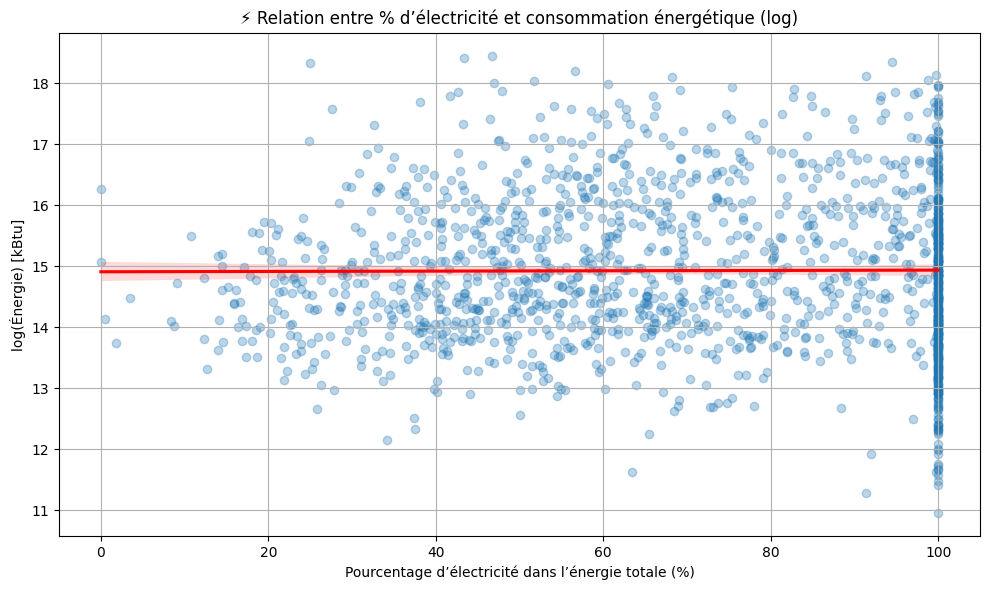

C:\Users\karap\AppData\Local\Temp\ipykernel_9124\3799161537.py:55: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\karap\OpenClassRooms\dataprojet6\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


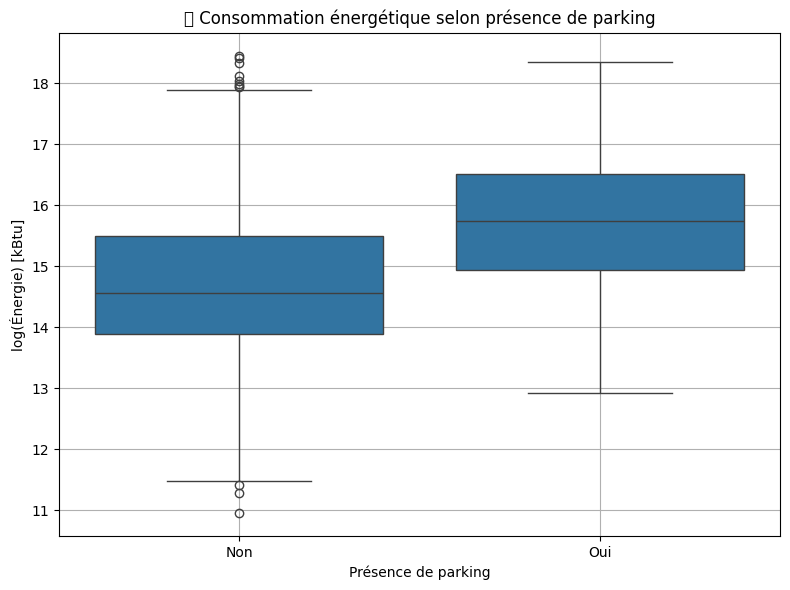

C:\Users\karap\AppData\Local\Temp\ipykernel_9124\3799161537.py:69: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\karap\OpenClassRooms\dataprojet6\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127981 (\N{FACTORY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


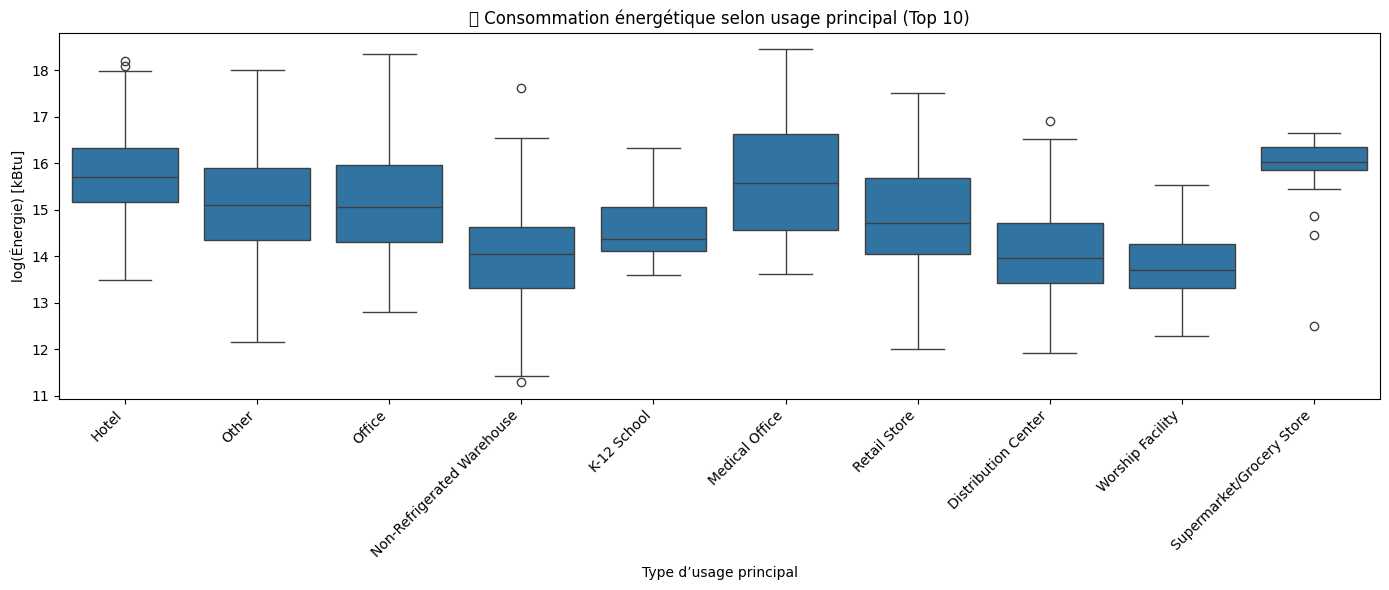

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 📂 Chargement des données
df = pd.read_csv("data/cleaned_2016_Building_Energy_Benchmarking_ML.csv")

# 🧹 Préparation
df = df[[
    "SiteEnergyUse(kBtu)",
    "Electricity(kBtu)",
    "SteamUse(kBtu)",
    "NaturalGas(kBtu)",
    "PropertyGFAParking",
    "LargestPropertyUseType"
]].copy()

df = df.dropna()
df = df[df["SiteEnergyUse(kBtu)"] > 0]

# 🔧 Variable log énergie
df["log_energy"] = np.log1p(df["SiteEnergyUse(kBtu)"])

# 🔧 Présence de parking
df["HasParking"] = df["PropertyGFAParking"] > 0

# 🔧 PourcentElec
df["TotalEnergy_kBtu"] = df["Electricity(kBtu)"] + df["SteamUse(kBtu)"] + df["NaturalGas(kBtu)"]
df["PourcentElec"] = (df["Electricity(kBtu)"] / df["TotalEnergy_kBtu"]) * 100
df["PourcentElec"] = df["PourcentElec"].round(2)
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["PourcentElec"])
df = df[df["PourcentElec"].between(0, 100)]

# ——————————————————————————————
# a) 📈 log énergie vs PourcentElec (nuage de points + régression)
plt.figure(figsize=(10, 6))
sns.regplot(x="PourcentElec", y="log_energy", data=df, scatter_kws={'alpha': 0.3}, line_kws={"color": "red"})
plt.title("⚡ Relation entre % d’électricité et consommation énergétique (log)")
plt.xlabel("Pourcentage d’électricité dans l’énergie totale (%)")
plt.ylabel("log(Énergie) [kBtu]")
plt.grid(True)
plt.tight_layout()
plt.show()

# ——————————————————————————————
# b) 📊 log énergie selon HasParking
plt.figure(figsize=(8, 6))
sns.boxplot(x="HasParking", y="log_energy", data=df)
plt.title("🚗 Consommation énergétique selon présence de parking")
plt.xlabel("Présence de parking")
plt.ylabel("log(Énergie) [kBtu]")
plt.xticks([0, 1], ["Non", "Oui"])
plt.grid(True)
plt.tight_layout()
plt.show()

# ——————————————————————————————
# c) 📊 log énergie selon usage principal
top_types = df["LargestPropertyUseType"].value_counts().nlargest(10).index
df_top = df[df["LargestPropertyUseType"].isin(top_types)]

plt.figure(figsize=(14, 6))
sns.boxplot(x="LargestPropertyUseType", y="log_energy", data=df_top)
plt.title("🏭 Consommation énergétique selon usage principal (Top 10)")
plt.xlabel("Type d’usage principal")
plt.ylabel("log(Énergie) [kBtu]")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 🧠 Feature Engineering : préparation des variables explicatives

Ce bloc de code construit un ensemble de variables prêtes à être utilisées dans un modèle de prédiction énergétique (par exemple une régression).
On part des données déjà nettoyées du fichier `cleaned_2016_Building_Energy_Benchmarking_ML.csv`.

---

### 📂 Chargement des données nettoyées

```python
df = pd.read_csv("data/cleaned_2016_Building_Energy_Benchmarking_ML.csv")
```

On charge les données finales, déjà débarrassées des valeurs aberrantes, doublons et colonnes inutiles.

---

### 🔧 Étape 1 — Transformation logarithmique de la surface utile

```python
df['log_surface'] = np.log1p(df['PropertyGFABuilding(s)'])
```

* La surface des bâtiments (`PropertyGFABuilding(s)`) peut varier énormément (de 100 m² à plusieurs centaines de milliers).
* Pour limiter l’impact des valeurs extrêmes, on applique une transformation **logarithmique** :
  [
  \text{log_surface} = \log(1 + \text{Surface})
  ]

---

### 🔧 Étape 2 — Détection de la présence d’un parking

```python
df['has_parking'] = (df['PropertyGFAParking'] > 0).astype(int)
```

* Cette variable binaire vaut :

  * `1` si le bâtiment dispose d’un parking,
  * `0` sinon.
* Cela permet de capturer un **effet indirect de taille ou d’usage**.

---

### 🔧 Étape 3 — Calcul de la part de l’électricité dans la consommation totale

```python
df['TotalEnergy_kBtu'] = df['Electricity(kBtu)'] + df['SteamUse(kBtu)'] + df['NaturalGas(kBtu)']
df['PourcentElec'] = (df['Electricity(kBtu)'] / df['TotalEnergy_kBtu']) * 100
```

* On additionne les trois sources d’énergie pour obtenir l’énergie totale.
* On calcule ensuite la **part de l’électricité** (en %) dans cette consommation.
* Cette variable (`PourcentElec`) donne une **information structurelle sur le type d’alimentation énergétique** du bâtiment :

  * Une valeur proche de **100%** → très électrifié (bureaux, immeubles modernes)
  * Une valeur proche de **0%** → plutôt alimenté en vapeur/gaz (bâtiments anciens, hôpitaux…)

On filtre ensuite les valeurs aberrantes :

```python
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["PourcentElec"])
df = df[df['PourcentElec'].between(0, 100)]
```

---

### 🔧 Étape 4 — Transformation logarithmique de la consommation énergétique

```python
df['log_energy'] = np.log1p(df['SiteEnergyUse(kBtu)'])
```

* On applique un **logarithme sur la consommation énergétique brute** pour la rendre **plus normalisée**, notamment en vue d’une modélisation.
* Cela permet aussi de **limiter l’influence des très gros bâtiments** sur l’entraînement.

---

### 🔧 Étape 5 — Regroupement des types d’usage rares

```python
type_counts = df['LargestPropertyUseType'].value_counts()
rare_types = type_counts[type_counts < 30].index
df['UseTypeGrouped'] = df['LargestPropertyUseType'].replace(rare_types, 'Other')
```

* Certains usages du bâtiment sont **très rares** (ex : aquarium, centrale thermique, etc.).
* On les regroupe dans une catégorie `Other` pour **éviter d’introduire trop de colonnes** dans l’encodage.

---

### 🔧 Étape 6 — Encodage One-Hot du type d’usage

```python
df = pd.get_dummies(df, columns=['UseTypeGrouped'], prefix='Use', drop_first=True)
```

* On convertit les usages (catégoriels) en colonnes numériques 0/1, compatibles avec les modèles de machine learning.
* L’option `drop_first=True` évite la redondance (régression multicolinéaire).

---

### ✅ Étape 7 — Définition des variables explicatives

```python
features_to_use = [
    'log_surface',
    'has_parking',
    'PourcentElec'
] + [col for col in df.columns if col.startswith('Use_')]
```

On construit la liste finale des **features** qui seront utilisées comme entrée (`X`) pour la modélisation.

---

### 🎯 Étape 8 — Séparation des données

```python
X = df[features_to_use]
y = df['log_energy']
```

* `X` : variables explicatives (features)
* `y` : cible à prédire (consommation énergétique, en log)

---

### 🔍 Résumé final

```python
print(X.describe().T[["mean", "std", "min", "max"]].round(2))
```

Affiche un **résumé statistique** des variables sélectionnées pour modélisation.

In [12]:
# 📂 Chargement des données nettoyées
df = pd.read_csv("data/cleaned_2016_Building_Energy_Benchmarking_ML.csv")

# 🔧 1. Log surface utile (évite les extrêmes)
df['log_surface'] = np.log1p(df['PropertyGFABuilding(s)'])

# 🔧 2. Présence de parking
df['has_parking'] = (df['PropertyGFAParking'] > 0).astype(int)

# 🔧 3. Pourcentage d’électricité dans l’énergie totale
df['TotalEnergy_kBtu'] = df['Electricity(kBtu)'] + df['SteamUse(kBtu)'] + df['NaturalGas(kBtu)']
df['PourcentElec'] = (df['Electricity(kBtu)'] / df['TotalEnergy_kBtu']) * 100
df['PourcentElec'] = df['PourcentElec'].round(2)
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["PourcentElec"])
df = df[df['PourcentElec'].between(0, 100)]

# 🔧 4. Log de la consommation énergétique (cible potentielle)
df['log_energy'] = np.log1p(df['SiteEnergyUse(kBtu)'])

# 🔧 5. Regroupement des types d’usage rares
df['LargestPropertyUseType'] = df['LargestPropertyUseType'].fillna("Unknown")
type_counts = df['LargestPropertyUseType'].value_counts()
rare_types = type_counts[type_counts < 30].index  # seuil modifiable
df['UseTypeGrouped'] = df['LargestPropertyUseType'].replace(rare_types, 'Other')

# 🔧 6. Encodage One-Hot du type d’usage
df = pd.get_dummies(df, columns=['UseTypeGrouped'], prefix='Use', drop_first=True)

# ✅ 7. Définition finale des variables explicatives
features_to_use = [
    'log_surface',
    'has_parking',
    'PourcentElec'
] + [col for col in df.columns if col.startswith('Use_')]

# ✅ 8. Séparation X / y
X = df[features_to_use]
y = df['log_energy']  # cible pour modélisation

# 🔍 Résumé
print("✅ Variables explicatives utilisées :")
print(X.describe().T[["mean", "std", "min", "max"]].round(2))

print(f"\n🧮 Total de features : {X.shape[1]}")
print("🔠 Liste : ", features_to_use)


✅ Variables explicatives utilisées :
               mean    std  min     max
log_surface   10.94   0.90  8.2   14.31
has_parking    0.21   0.41  0.0    1.00
PourcentElec  70.36  26.28  0.0  100.00

🧮 Total de features : 14
🔠 Liste :  ['log_surface', 'has_parking', 'PourcentElec', 'Use_Hotel', 'Use_K-12 School', 'Use_Medical Office', 'Use_Non-Refrigerated Warehouse', 'Use_Office', 'Use_Other', 'Use_Other - Recreation', 'Use_Parking', 'Use_Retail Store', 'Use_Supermarket/Grocery Store', 'Use_Worship Facility']
